# live demo

In [2]:
# =============================================================================
# CISLR REAL-TIME SIGN RECOGNITION DEMO
# =============================================================================
# Single-cell consolidated version.
#
# SCIENTIFIC FRAMING:
#   This is a PROTOTYPE RETRIEVAL DEMONSTRATION.
#   It is NOT a sign-language translator.
#   It is NOT a sentence translator.
#   It performs isolated-gloss retrieval against the frozen CISLR
#   prototype vocabulary using the frozen Stage 5.5 MobileNetV3-Large
#   embedding pipeline.
#
# WHAT IT DOES:
#   Webcam frame
#      -> 8-frame temporal buffer
#      -> MobileNetV3-Large (frozen ImageNet1K_V2, 960-D penultimate)
#      -> mean-pool 8 frame embeddings
#      -> L2 normalize
#      -> cosine similarity against frozen prototype bank
#      -> Top-K CISLR prototype glosses
#
# WHAT IT DOES NOT DO:
#   - No retraining
#   - No modification of Stage 5.5 / 5.6 / 5.7 artifacts
#   - No modification of dataset.csv / prototype.csv / test.csv
#   - No test-set tuning
#   - No sentence-level translation
#
# KEYBOARD CONTROLS:
#   F  = FULL_FRAME mode
#   R  = HAND_ROI mode
#   S  = save screenshot
#   C  = clear temporal buffer
#   T  = toggle top-5 display
#   Q  = quit
#
# EXPECTED ACCURACY:
#   Stage 5.5 in-domain Top-1  = 12.99%
#   Webcam is out-of-domain; expect lower.
#   This is a smoke test that the pipeline runs end-to-end.
# =============================================================================


# -----------------------------------------------------------------------------
# 0. IMPORTS
# -----------------------------------------------------------------------------

import os
import sys
import json
import time
import platform
import statistics
from pathlib import Path
from collections import deque, Counter
from datetime import datetime

import numpy as np
import pandas as pd

import cv2

import torch
import torch.nn as nn
from torchvision import models, transforms


# -----------------------------------------------------------------------------
# 1. ENVIRONMENT AUDIT
# -----------------------------------------------------------------------------

print("=" * 90)
print("CISLR REAL-TIME SIGN RECOGNITION — ENVIRONMENT AUDIT")
print("=" * 90)

print(f"Python       : {sys.version.split()[0]}")
print(f"Platform     : {platform.platform()}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"OpenCV       : {cv2.__version__}")
print(f"PyTorch      : {torch.__version__}")

CUDA_AVAILABLE = torch.cuda.is_available()
print(f"CUDA         : {CUDA_AVAILABLE}")
if CUDA_AVAILABLE:
    print(f"CUDA version : {torch.version.cuda}")
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device       : {DEVICE}")


# -----------------------------------------------------------------------------
# 2. PATHS + DEMO DIRECTORIES
# -----------------------------------------------------------------------------

PROJECT_ROOT  = Path("/home/dipshikha/Music/cao")
RESEARCH_ROOT = PROJECT_ROOT / "CISLR_RESEARCH"
STAGE5_ROOT   = RESEARCH_ROOT / "audit" / "stage5_hand_roi"

DEMO_ROOT       = RESEARCH_ROOT / "realtime_demo"
LOGS_DIR        = DEMO_ROOT / "logs"
SCREENSHOTS_DIR = DEMO_ROOT / "screenshots"
REPORTS_DIR     = DEMO_ROOT / "reports"

for p in [DEMO_ROOT, LOGS_DIR, SCREENSHOTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"\nDemo root : {DEMO_ROOT}")


# -----------------------------------------------------------------------------
# 3. FROZEN ARTIFACT DISCOVERY
# -----------------------------------------------------------------------------
# We walk the frozen Stage 5 directories and select the exact file we need.
# No filename is invented.
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("FROZEN ARTIFACT DISCOVERY")
print("=" * 90)

FF_DIR = STAGE5_ROOT / "full_frame_baseline"

if not FF_DIR.exists():
    raise FileNotFoundError(f"Stage 5.5 directory missing: {FF_DIR}")

ff_npys = sorted(FF_DIR.rglob("*.npy"))
ff_csvs = sorted(FF_DIR.rglob("*.csv"))

print(f"Stage 5.5 .npy files: {len(ff_npys)}")
for p in ff_npys:
    print(f"  {p.relative_to(FF_DIR)}  ({p.stat().st_size / 1e6:.2f} MB)")

print(f"Stage 5.5 .csv files: {len(ff_csvs)}")
for p in ff_csvs:
    print(f"  {p.relative_to(FF_DIR)}")

# Select embedding matrix: prefer a file with "embedding" in the name
FF_EMBEDDINGS_PATH = None
for p in ff_npys:
    if "embedding" in p.name.lower():
        FF_EMBEDDINGS_PATH = p
        break
if FF_EMBEDDINGS_PATH is None and ff_npys:
    FF_EMBEDDINGS_PATH = ff_npys[0]

# Select UID manifest: prefer a .csv with "uid" or "manifest"
FF_UID_MANIFEST_PATH = None
for p in ff_csvs:
    n = p.name.lower()
    if ("embedding" in n and "manifest" in n) or ("embedding" in n and "uid" in n):
        FF_UID_MANIFEST_PATH = p
        break
if FF_UID_MANIFEST_PATH is None:
    for p in ff_csvs:
        if "uid" in p.name.lower():
            FF_UID_MANIFEST_PATH = p
            break

if FF_EMBEDDINGS_PATH is None:
    raise FileNotFoundError("Could not find full-frame embedding matrix (.npy).")
if FF_UID_MANIFEST_PATH is None:
    raise FileNotFoundError("Could not find full-frame UID manifest (.csv).")

print(f"\nSelected full-frame embeddings : {FF_EMBEDDINGS_PATH}")
print(f"Selected UID manifest          : {FF_UID_MANIFEST_PATH}")

# Original metadata
PROTOTYPE_CSV = PROJECT_ROOT / "prototype.csv"
if not PROTOTYPE_CSV.exists():
    raise FileNotFoundError(PROTOTYPE_CSV)
print(f"prototype.csv                  : {PROTOTYPE_CSV}")


# -----------------------------------------------------------------------------
# 4. FROZEN MOBILENETV3-LARGE
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("LOADING FROZEN MOBILENETV3-LARGE (960-D penultimate)")
print("=" * 90)

class MobileNetV3Large960(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)


backbone = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
)
embedding_model = MobileNetV3Large960(backbone).eval().to(DEVICE)
for p in embedding_model.parameters():
    p.requires_grad = False

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Preprocessing : Resize(256) -> CenterCrop(224) -> ToTensor -> ImageNet Norm")
print("✓ MobileNetV3-Large frozen and ready.")


# -----------------------------------------------------------------------------
# 5. EMBEDDING FUNCTION
# -----------------------------------------------------------------------------

def extract_embedding_from_frame(frame_bgr):
    """Return a 960-D L2-normalized embedding for a single BGR frame."""
    rgb = frame_bgr[:, :, ::-1]
    tensor = preprocess(np.ascontiguousarray(rgb)).unsqueeze(0).to(DEVICE)
    with torch.inference_mode():
        z = embedding_model(tensor)
        z = torch.nn.functional.normalize(z, p=2, dim=1)
    return z.squeeze(0).cpu().numpy().astype(np.float32)


# Verify
_dummy = np.zeros((720, 1280, 3), dtype=np.uint8)
_e = extract_embedding_from_frame(_dummy)
assert _e.shape == (960,), f"Expected (960,), got {_e.shape}"
assert abs(float(np.linalg.norm(_e)) - 1.0) < 1e-4, "Embedding not L2-normalized."
print(f"✓ Embedding shape = {_e.shape}, L2 norm = {float(np.linalg.norm(_e)):.6f}")

# CUDA warm-up
if DEVICE.type == "cuda":
    print("CUDA warm-up...")
    for _ in range(5):
        _ = extract_embedding_from_frame(_dummy)
    torch.cuda.synchronize()


# -----------------------------------------------------------------------------
# 6. LOAD PROTOTYPE VOCABULARY
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("LOADING PROTOTYPE VOCABULARY")
print("=" * 90)

prototype_df = pd.read_csv(PROTOTYPE_CSV, low_memory=False)
print(f"prototype.csv shape : {prototype_df.shape}")
print(f"prototype.csv cols  : {list(prototype_df.columns)}")

def _detect_uid_col(df):
    for c in ["uid", "UID", "video_id", "video", "video_uid"]:
        if c in df.columns:
            return c
    raise KeyError(f"No UID column. Columns: {list(df.columns)}")

def _detect_gloss_col(df):
    for c in ["gloss", "Gloss", "label", "class", "category"]:
        if c in df.columns:
            return c
    raise KeyError(f"No gloss column. Columns: {list(df.columns)}")

PROTO_UID_COL   = _detect_uid_col(prototype_df)
PROTO_GLOSS_COL = _detect_gloss_col(prototype_df)

print(f"Detected UID col   : {PROTO_UID_COL}")
print(f"Detected gloss col : {PROTO_GLOSS_COL}")

prototype_df[PROTO_UID_COL]   = prototype_df[PROTO_UID_COL].astype(str).str.strip()
prototype_df[PROTO_GLOSS_COL] = prototype_df[PROTO_GLOSS_COL].astype(str)

prototype_df = prototype_df[prototype_df[PROTO_GLOSS_COL].notna()]
prototype_df = prototype_df[prototype_df[PROTO_GLOSS_COL].str.strip() != ""]

print(f"Prototype rows       : {len(prototype_df)}")
print(f"Unique UIDs          : {prototype_df[PROTO_UID_COL].nunique()}")
print(f"Unique glosses       : {prototype_df[PROTO_GLOSS_COL].nunique()}")


# -----------------------------------------------------------------------------
# 7. BUILD PROTOTYPE EMBEDDING BANK (from frozen Stage 5.5 matrix)
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("BUILDING PROTOTYPE EMBEDDING BANK")
print("=" * 90)

_all_emb = np.load(FF_EMBEDDINGS_PATH).astype(np.float32)
print(f"Embedding matrix shape : {_all_emb.shape}")

_uid_manifest = pd.read_csv(FF_UID_MANIFEST_PATH)
print(f"UID manifest shape     : {_uid_manifest.shape}")
print(f"UID manifest columns   : {list(_uid_manifest.columns)}")

_uid_col_candidates   = ["uid", "UID", "video_id", "video", "video_uid"]
_index_col_candidates = ["embedding_index", "index", "row", "idx", "row_index"]

MANIFEST_UID_COL = next((c for c in _uid_col_candidates if c in _uid_manifest.columns), None)
MANIFEST_INDEX_COL = next((c for c in _index_col_candidates if c in _uid_manifest.columns), None)

if MANIFEST_UID_COL is None:
    raise KeyError(f"No UID column in manifest: {list(_uid_manifest.columns)}")

if MANIFEST_INDEX_COL is None:
    # Assume manifest order == embedding row order
    _uid_manifest = _uid_manifest.reset_index(drop=True)
    _uid_manifest["__row__"] = _uid_manifest.index
    MANIFEST_INDEX_COL = "__row__"

_uid_manifest[MANIFEST_UID_COL] = _uid_manifest[MANIFEST_UID_COL].astype(str).str.strip()

uid_to_row = dict(zip(
    _uid_manifest[MANIFEST_UID_COL],
    _uid_manifest[MANIFEST_INDEX_COL].astype(int),
))

# Match prototype UIDs
matched_rows    = []
matched_glosses = []
matched_uids    = []
missing_uids    = []

for uid, gloss in zip(
    prototype_df[PROTO_UID_COL].tolist(),
    prototype_df[PROTO_GLOSS_COL].tolist(),
):
    if uid in uid_to_row:
        row_idx = uid_to_row[uid]
        if 0 <= row_idx < _all_emb.shape[0]:
            matched_rows.append(row_idx)
            matched_glosses.append(gloss)
            matched_uids.append(uid)
        else:
            missing_uids.append(uid)
    else:
        missing_uids.append(uid)

print(f"\nPrototype UIDs requested : {len(prototype_df)}")
print(f"Prototype UIDs matched   : {len(matched_uids)}")
print(f"Prototype UIDs missing   : {len(missing_uids)}")

if len(matched_uids) == 0:
    raise RuntimeError("No prototype embeddings matched. Cannot proceed.")

matched_rows = np.asarray(matched_rows, dtype=np.int64)
PROTOTYPE_BANK = _all_emb[matched_rows]

# Re-verify L2 norm
_norms = np.linalg.norm(PROTOTYPE_BANK, axis=1, keepdims=True)
_norms[_norms == 0] = 1.0
PROTOTYPE_BANK = (PROTOTYPE_BANK / _norms).astype(np.float32)

PROTOTYPE_GLOSSES      = np.asarray(matched_glosses)
PROTOTYPE_UIDS_ORDERED = np.asarray(matched_uids)

print(f"\nPrototype bank shape : {PROTOTYPE_BANK.shape}")
print(f"Prototype bank dtype : {PROTOTYPE_BANK.dtype}")

_n = np.linalg.norm(PROTOTYPE_BANK, axis=1)
print(f"L2 norms: min={_n.min():.6f}  max={_n.max():.6f}")

# Persist for reference
np.save(DEMO_ROOT / "prototype_bank.npy", PROTOTYPE_BANK)
np.save(DEMO_ROOT / "prototype_glosses.npy", PROTOTYPE_GLOSSES)
print(f"Saved prototype bank cache to {DEMO_ROOT}")


# -----------------------------------------------------------------------------
# 8. COSINE RETRIEVAL
# -----------------------------------------------------------------------------

def retrieve_top_k(query_embedding, k=5):
    """Query: 960-D L2-normalized. Bank: (N, 960) L2-normalized."""
    q = query_embedding.astype(np.float32)
    n = np.linalg.norm(q)
    if n > 0:
        q = q / n

    sims = PROTOTYPE_BANK @ q

    k_eff = min(k, len(sims))
    top_idx = np.argpartition(-sims, k_eff - 1)[:k_eff]
    top_idx = top_idx[np.argsort(-sims[top_idx])]

    return [(rank, str(PROTOTYPE_GLOSSES[idx]), float(sims[idx]))
            for rank, idx in enumerate(top_idx, start=1)]


# -----------------------------------------------------------------------------
# 9. HAND ROI DETECTOR (frozen Stage 5.2/5.3 parameters)
# -----------------------------------------------------------------------------

HSV_LOWER        = np.array([0, 20, 40],     dtype=np.uint8)
HSV_UPPER        = np.array([35, 255, 255],  dtype=np.uint8)
YCRCB_LOWER      = np.array([0, 133, 77],    dtype=np.uint8)
YCRCB_UPPER      = np.array([255, 173, 127], dtype=np.uint8)
MORPH_KERNEL     = 5
MIN_CONTOUR_AREA = 150

ROI_MIN_AREA_FRACTION = 0.005
ROI_MAX_AREA_FRACTION = 0.90
CROP_PADDING_FACTOR   = 0.35
OUTPUT_SIZE           = 224


def _clamp_box(x1, y1, x2, y2, w, h):
    x1 = max(0, min(int(round(x1)), w - 1))
    y1 = max(0, min(int(round(y1)), h - 1))
    x2 = max(0, min(int(round(x2)), w - 1))
    y2 = max(0, min(int(round(y2)), h - 1))
    if x2 <= x1 or y2 <= y1:
        return None
    return (x1, y1, x2, y2)


def _merge_boxes(boxes, w, h):
    valid = [b for b in boxes if b is not None]
    if not valid:
        return None
    x1 = min(b[0] for b in valid)
    y1 = min(b[1] for b in valid)
    x2 = max(b[2] for b in valid)
    y2 = max(b[3] for b in valid)
    return _clamp_box(x1, y1, x2, y2, w, h)


def detect_opencv_skin_contour(frame_bgr):
    h, w = frame_bgr.shape[:2]
    frame_area = float(w * h)

    hsv   = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)

    mask_hsv   = cv2.inRange(hsv,   HSV_LOWER,   HSV_UPPER)
    mask_ycrcb = cv2.inRange(ycrcb, YCRCB_LOWER, YCRCB_UPPER)
    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    kernel = np.ones((MORPH_KERNEL, MORPH_KERNEL), dtype=np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < MIN_CONTOUR_AREA:
            continue
        x, y, bw, bh = cv2.boundingRect(c)
        if bw <= 0 or bh <= 0:
            continue
        frac = float(bw * bh) / frame_area
        if frac < ROI_MIN_AREA_FRACTION or frac > ROI_MAX_AREA_FRACTION:
            continue
        candidates.append({"area": float(area), "x1": x, "y1": y,
                            "x2": x + bw, "y2": y + bh})

    if not candidates:
        return None, 0.0, 0

    candidates = sorted(candidates, key=lambda c: c["area"], reverse=True)[:2]

    x1 = min(c["x1"] for c in candidates)
    y1 = min(c["y1"] for c in candidates)
    x2 = max(c["x2"] for c in candidates)
    y2 = max(c["y2"] for c in candidates)

    merged_frac = float((x2 - x1) * (y2 - y1)) / frame_area
    if merged_frac < ROI_MIN_AREA_FRACTION or merged_frac > ROI_MAX_AREA_FRACTION:
        return None, 0.0, len(candidates)

    conf = min(sum(c["area"] for c in candidates) / frame_area, 1.0)
    return (x1, y1, x2, y2), float(conf), len(candidates)


def crop_square_with_padding(frame_bgr, roi_box):
    h, w = frame_bgr.shape[:2]
    x1, y1, x2, y2 = roi_box

    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    side = max(bw, bh) * (1.0 + CROP_PADDING_FACTOR)

    cx1 = int(round(cx - side / 2))
    cy1 = int(round(cy - side / 2))
    cx2 = int(round(cx + side / 2))
    cy2 = int(round(cy + side / 2))

    if cx1 < 0:
        s = -cx1; cx1 += s; cx2 += s
    if cy1 < 0:
        s = -cy1; cy1 += s; cy2 += s
    if cx2 > w:
        s = cx2 - w; cx1 -= s; cx2 -= s
    if cy2 > h:
        s = cy2 - h; cy1 -= s; cy2 -= s

    cx1 = max(0, cx1); cy1 = max(0, cy1)
    cx2 = min(w, cx2); cy2 = min(h, cy2)

    if cx2 <= cx1 or cy2 <= cy1:
        return None, None

    crop = frame_bgr[cy1:cy2, cx1:cx2]
    if crop.size == 0:
        return None, None

    resized = cv2.resize(crop, (OUTPUT_SIZE, OUTPUT_SIZE),
                         interpolation=cv2.INTER_AREA)
    return resized, (cx1, cy1, cx2, cy2)


def prepare_model_input(frame_bgr, previous_valid_roi, mode):
    """
    Returns (input_224, roi_status, roi_box, new_previous).
    """
    if mode == "FULL_FRAME":
        resized = cv2.resize(frame_bgr, (OUTPUT_SIZE, OUTPUT_SIZE),
                             interpolation=cv2.INTER_AREA)
        return resized, "FULL_FRAME_MODE", None, None

    roi_box, _conf, _n = detect_opencv_skin_contour(frame_bgr)
    if roi_box is not None:
        crop, _cb = crop_square_with_padding(frame_bgr, roi_box)
        if crop is not None:
            return crop, "DETECTED", roi_box, roi_box

    if previous_valid_roi is not None:
        crop, _cb = crop_square_with_padding(frame_bgr, previous_valid_roi)
        if crop is not None:
            return crop, "TEMPORAL_FALLBACK", previous_valid_roi, previous_valid_roi

    resized = cv2.resize(frame_bgr, (OUTPUT_SIZE, OUTPUT_SIZE),
                         interpolation=cv2.INTER_AREA)
    return resized, "FULL_FRAME_FALLBACK", None, previous_valid_roi


# -----------------------------------------------------------------------------
# 10. CONFIGURATION
# -----------------------------------------------------------------------------

# Demonstration threshold. NOT tuned on the CISLR test set.
# If the top-1 similarity is below this, we display "UNKNOWN".
UNKNOWN_THRESHOLD = 0.20

# Smoothing window (majority vote across last N completed predictions)
SMOOTHING_WINDOW = 5

# Temporal buffer size matches the frozen Stage 5 protocol
TEMPORAL_WINDOW = 8

# Run inference every N frames (buffer must be full)
INFERENCE_EVERY = 4


# -----------------------------------------------------------------------------
# 11. REAL-TIME DEMO
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("STARTING REAL-TIME DEMO")
print("=" * 90)
print("Controls:")
print("  F = FULL_FRAME mode")
print("  R = HAND_ROI mode")
print("  S = save screenshot")
print("  C = clear temporal buffer")
print("  T = toggle top-5 display")
print("  Q = quit")
print("=" * 90)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    # Try V4L2 backend explicitly on Linux
    cap = cv2.VideoCapture(0, cv2.CAP_V4L2)

if not cap.isOpened():
    raise RuntimeError(
        "Could not open webcam. Check:\n"
        "  - Camera connected\n"
        "  - Permission to /dev/video0\n"
        "  - No other app is using the camera"
    )

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
cap.set(cv2.CAP_PROP_FPS, 30)

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS_CAP = cap.get(cv2.CAP_PROP_FPS)
print(f"Webcam : {W}x{H} @ {FPS_CAP:.1f} FPS")

# State
mode = "HAND_ROI"
frame_buffer = deque(maxlen=TEMPORAL_WINDOW)
prediction_history = deque(maxlen=SMOOTHING_WINDOW)

previous_valid_roi = None
frozen = False
show_top5 = True
frame_count = 0

# Latest prediction state
current_prediction = None       # (rank1_gloss, rank1_sim, is_unknown)
current_topk = None             # list of (rank, gloss, sim)
current_roi_status = "-"
current_latency_ms = 0.0

# Logging
inference_log = []
latencies_buffer = []
roi_status_counter = Counter()

# FPS tracking (rolling)
fps_times = deque(maxlen=30)

# Main loop
try:
    while True:
        t_frame_start = time.perf_counter()

        ok, frame_bgr = cap.read()
        if not ok or frame_bgr is None:
            print("Frame read failed. Exiting.")
            break

        frame_count += 1
        display = frame_bgr.copy()

        # ---- Inference ----
        if not frozen:
            # Prepare model input for this frame (ROI detection happens here)
            model_input, roi_status, roi_box, previous_valid_roi = prepare_model_input(
                frame_bgr, previous_valid_roi, mode
            )
            current_roi_status = roi_status
            roi_status_counter[roi_status] += 1

            frame_buffer.append(model_input)

            if (len(frame_buffer) == TEMPORAL_WINDOW
                    and frame_count % INFERENCE_EVERY == 0):

                t_inf = time.perf_counter()

                # Embed each of the 8 buffered 224x224 BGR crops
                emb_list = []
                for f224 in frame_buffer:
                    e = extract_embedding_from_frame(f224)
                    emb_list.append(e)

                emb_stack = np.stack(emb_list, axis=0)   # (8, 960)

                # Mean-pool and L2-normalize
                pooled = emb_stack.mean(axis=0)
                pnorm = np.linalg.norm(pooled)
                if pnorm > 0:
                    pooled = pooled / pnorm

                # Top-k retrieval
                topk = retrieve_top_k(pooled, k=5)

                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()

                current_latency_ms = (time.perf_counter() - t_inf) * 1000.0
                latencies_buffer.append(current_latency_ms)

                top1_gloss = topk[0][1]
                top1_sim   = topk[0][2]

                is_unknown = top1_sim < UNKNOWN_THRESHOLD
                current_topk = topk

                if is_unknown:
                    current_prediction = ("UNKNOWN", top1_sim, True)
                else:
                    current_prediction = (top1_gloss, top1_sim, False)

                # Smoothing history (store only the top-1 label)
                prediction_history.append(
                    "UNKNOWN" if is_unknown else top1_gloss
                )

                # Log
                inference_log.append({
                    "timestamp": datetime.now().isoformat(),
                    "mode": mode,
                    "prediction_raw": top1_gloss,
                    "prediction_display": current_prediction[0],
                    "similarity": top1_sim,
                    "is_unknown": bool(is_unknown),
                    "top5_glosses": "|".join(g for _, g, _ in topk),
                    "top5_sims":    "|".join(f"{s:.4f}" for _, _, s in topk),
                    "roi_status": roi_status,
                    "latency_ms": current_latency_ms,
                    "buffer_size": len(frame_buffer),
                    "frame_count": frame_count,
                })

        # ---- Draw ROI box if present ----
        if current_roi_status in ("DETECTED", "TEMPORAL_FALLBACK") and previous_valid_roi is not None:
            x1, y1, x2, y2 = previous_valid_roi
            color = (0, 255, 0) if current_roi_status == "DETECTED" else (0, 200, 255)
            cv2.rectangle(display, (x1, y1), (x2, y2), color, 2)
            cv2.putText(display, current_roi_status,
                        (x1, max(y1 - 8, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

        # ---- HUD ----
        h, w = display.shape[:2]

        # Top panel
        overlay = display.copy()
        cv2.rectangle(overlay, (0, 0), (w, 250), (0, 0, 0), -1)
        display = cv2.addWeighted(overlay, 0.55, display, 0.45, 0)

        # Title
        cv2.putText(display, "CISLR PROTOTYPE RETRIEVAL DEMO",
                    (12, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 255), 2)
        cv2.putText(display,
                    "Not a certified translator — isolated gloss retrieval only",
                    (12, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1)

        # FPS
        fps_times.append(time.perf_counter())
        if len(fps_times) >= 2:
            dt = fps_times[-1] - fps_times[0]
            fps_now = (len(fps_times) - 1) / dt if dt > 0 else 0.0
        else:
            fps_now = 0.0

        # Mode + status
        cv2.putText(display, f"Mode: {mode}",
                    (12, 78), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

        cv2.putText(display, f"ROI: {current_roi_status}",
                    (12, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

        cv2.putText(display,
                    f"Buffer: {len(frame_buffer)}/{TEMPORAL_WINDOW}   "
                    f"FPS: {fps_now:5.1f}   "
                    f"Latency: {current_latency_ms:6.1f} ms",
                    (12, 122), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

        # Prediction
        if current_prediction is not None:
            label, sim, is_unk = current_prediction
            if is_unk:
                color = (100, 100, 255)
                text = f"Prediction: UNKNOWN  (sim {sim:.4f})"
            else:
                color = (0, 255, 0)
                text = f"Prediction: {label}  (sim {sim:.4f})"

            # Majority-vote display label
            if prediction_history:
                vote = Counter(prediction_history).most_common(1)[0][0]
                vote_text = f"Stable: {vote}   (window {len(prediction_history)})"
            else:
                vote_text = "Stable: -"

            cv2.putText(display, text, (12, 152),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2)
            cv2.putText(display, vote_text, (12, 178),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        else:
            cv2.putText(display,
                        "Collecting frames — hold a sign steady for ~1 second",
                        (12, 152), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (100, 200, 255), 1)

        # Top-5
        if show_top5 and current_topk is not None:
            cv2.putText(display, "Top-5 (prototype retrieval, cosine similarity):",
                        (12, 205), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            y = 225
            for rank, gloss, sim in current_topk:
                col = (0, 255, 0) if rank == 1 else (180, 180, 180)
                th = 2 if rank == 1 else 1
                cv2.putText(display,
                            f"{rank}. {gloss:<22s}  {sim:+.4f}",
                            (24, y),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, th)
                y += 20

        # Footer
        cv2.putText(display,
                    "F:FullFrame  R:HandROI  S:screenshot  C:clear  T:top5  Q:quit",
                    (12, h - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

        cv2.imshow("CISLR Real-Time Sign Recognition Demo", display)

        key = cv2.waitKey(1) & 0xFF

        if key == ord("q"):
            break
        elif key == ord("f"):
            mode = "FULL_FRAME"
            frame_buffer.clear()
            prediction_history.clear()
            previous_valid_roi = None
            print("Mode: FULL_FRAME")
        elif key == ord("r"):
            mode = "HAND_ROI"
            frame_buffer.clear()
            prediction_history.clear()
            previous_valid_roi = None
            print("Mode: HAND_ROI")
        elif key == ord("s"):
            ts = datetime.now().strftime("%Y%m%d_%H%M%S")
            fname = SCREENSHOTS_DIR / f"realtime_{mode.lower()}_{ts}.jpg"
            cv2.imwrite(str(fname), display)
            print(f"Screenshot saved: {fname}")
        elif key == ord("c"):
            frame_buffer.clear()
            prediction_history.clear()
            print("Buffer cleared.")
        elif key == ord("t"):
            show_top5 = not show_top5
            print(f"Top-5 display: {'ON' if show_top5 else 'OFF'}")

except KeyboardInterrupt:
    print("\nInterrupted by user.")
finally:
    cap.release()
    cv2.destroyAllWindows()


# -----------------------------------------------------------------------------
# 12. FINAL REPORT
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("SAVING DEMO REPORT")
print("=" * 90)

# Inference log
if inference_log:
    log_df = pd.DataFrame(inference_log)
    log_path = LOGS_DIR / "realtime_inference_log.csv"
    log_df.to_csv(log_path, index=False)
    print(f"Saved inference log : {log_path}  ({len(log_df)} rows)")
else:
    log_path = None
    print("No inference entries were logged.")

# Latency stats
if latencies_buffer:
    lat = np.asarray(latencies_buffer, dtype=np.float64)
    mean_lat  = float(lat.mean())
    median_lat = float(np.median(lat))
    p95_lat   = float(np.percentile(lat, 95))
    mean_fps  = 1000.0 / mean_lat if mean_lat > 0 else 0.0
else:
    mean_lat = median_lat = p95_lat = mean_fps = 0.0

# ROI fallback stats
total_frames_processed = sum(roi_status_counter.values())
if total_frames_processed > 0:
    detected = roi_status_counter.get("DETECTED", 0)
    temporal = roi_status_counter.get("TEMPORAL_FALLBACK", 0)
    fullfb   = roi_status_counter.get("FULL_FRAME_FALLBACK", 0)
    roi_detection_rate = detected / total_frames_processed
    roi_fallback_rate  = (temporal + fullfb) / total_frames_processed
else:
    roi_detection_rate = roi_fallback_rate = 0.0

summary = {
    "stage": "realtime_demo",
    "timestamp": datetime.now().isoformat(),
    "scientific_label": "Prototype Retrieval Demonstration (not a translator)",
    "model": "MobileNetV3-Large (ImageNet1K_V2, frozen)",
    "embedding_dimension": 960,
    "device": str(DEVICE),
    "mode_at_exit": mode,
    "temporal_window": TEMPORAL_WINDOW,
    "inference_every_n_frames": INFERENCE_EVERY,
    "smoothing_window": SMOOTHING_WINDOW,
    "unknown_threshold": UNKNOWN_THRESHOLD,
    "unknown_threshold_note": "Demonstration threshold, NOT tuned on CISLR test set",
    "prototype_count": int(PROTOTYPE_BANK.shape[0]),
    "mean_latency_ms": mean_lat,
    "median_latency_ms": median_lat,
    "p95_latency_ms": p95_lat,
    "mean_fps": mean_fps,
    "roi_detection_rate": roi_detection_rate,
    "roi_fallback_rate": roi_fallback_rate,
    "number_of_predictions": len(inference_log),
    "frames_processed": frame_count,
    "accuracy_reported": False,
    "accuracy_note": "No webcam ground-truth labels; accuracy not reported.",
    "frozen_artifacts_touched": False,
    "test_set_used_for_tuning": False,
}

summary_path = REPORTS_DIR / "realtime_demo_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary       : {summary_path}")

print("\n" + "=" * 90)
print("DEMO SUMMARY")
print("=" * 90)
for k, v in summary.items():
    print(f"  {k:<32}: {v}")

print("\n" + "=" * 90)
print("REMINDER")
print("=" * 90)
print("This was a PROTOTYPE RETRIEVAL DEMONSTRATION.")
print("It is NOT a certified sign-language translator.")
print("In-domain Top-1 on CISLR test set = 12.99% (Stage 5.5).")
print("Webcam predictions are out-of-domain and unvalidated.")
print("Stage 5.5 / 5.6 / 5.7 artifacts were NOT modified.")
print("=" * 90)

CISLR REAL-TIME SIGN RECOGNITION — ENVIRONMENT AUDIT
Python       : 3.11.15
Platform     : Linux-7.0.0-31-generic-x86_64-with-glibc2.39
NumPy        : 2.4.6
Pandas       : 3.0.5
OpenCV       : 5.0.0
PyTorch      : 2.14.0+cu130
CUDA         : True
CUDA version : 13.0
GPU          : NVIDIA GeForce RTX 4050 Laptop GPU
Device       : cuda

Demo root : /home/dipshikha/Music/cao/CISLR_RESEARCH/realtime_demo

FROZEN ARTIFACT DISCOVERY
Stage 5.5 .npy files: 1
  embeddings/stage5_5_full_frame_embeddings.npy  (25.45 MB)
Stage 5.5 .csv files: 4
  embeddings/stage5_5_full_frame_embedding_uid_manifest.csv
  reports/stage5_5_documented_exclusions.csv
  reports/stage5_5_embedding_errors.csv
  reports/stage5_5_full_frame_retrieval_results.csv

Selected full-frame embeddings : /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage5_hand_roi/full_frame_baseline/embeddings/stage5_5_full_frame_embeddings.npy
Selected UID manifest          : /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage5_hand_roi/full

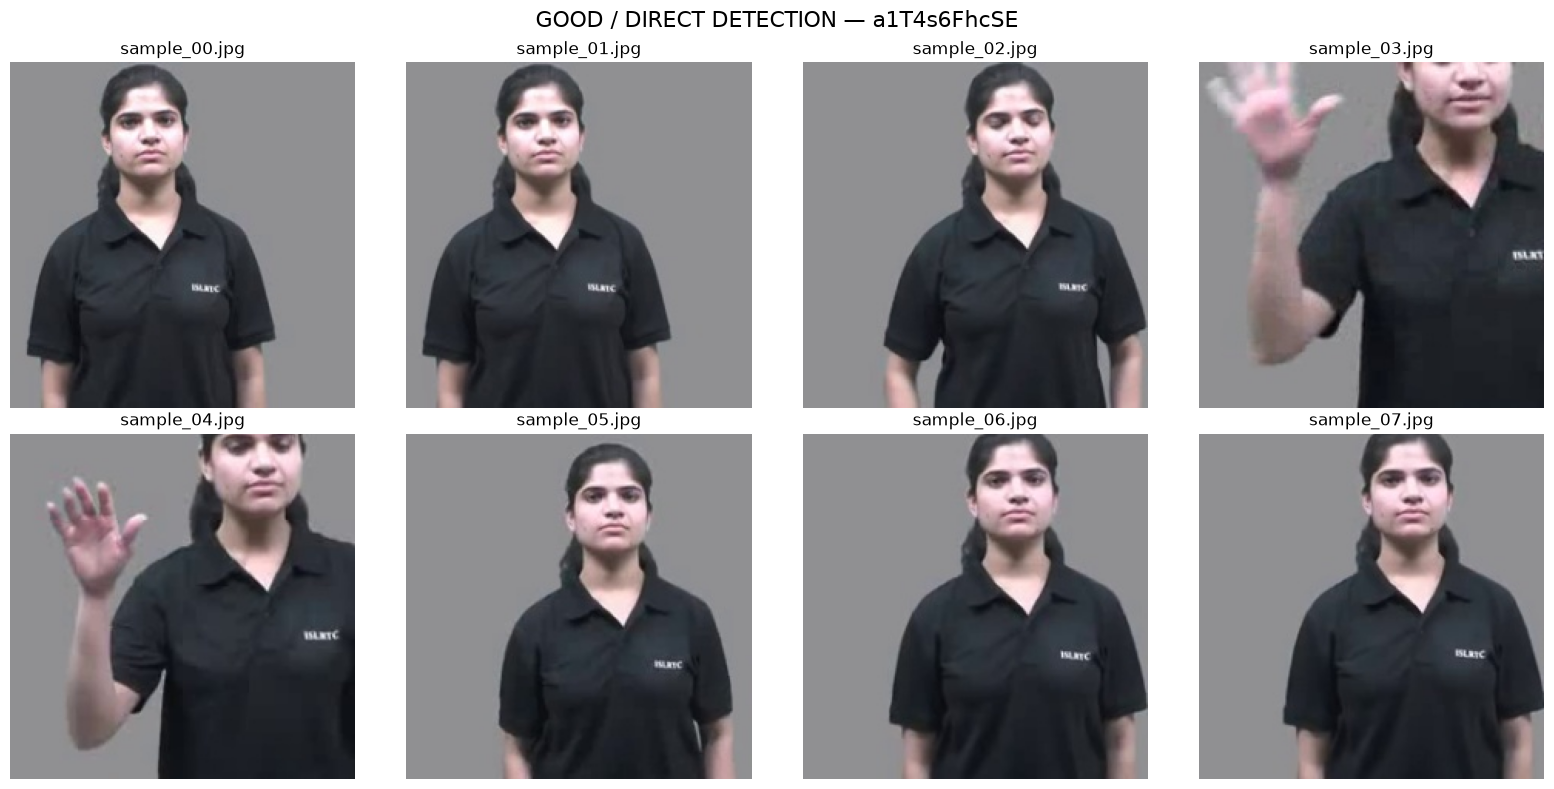

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

folder = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH/"
    "audit/stage5_hand_roi/roi_dataset/"
    "a1T4s6FhcSE_fba53949"
)

images = sorted(
    folder.glob("sample_*.jpg"),
    key=lambda p: int(p.stem.split("_")[-1])
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, path in enumerate(images):
    img = Image.open(path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(path.name)
    axes[i].axis("off")

plt.suptitle(
    "GOOD / DIRECT DETECTION — a1T4s6FhcSE",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# CISLR — STAGE 9.2 PRECHECK
# LOCATE THE EXACT DATA / METADATA NEEDED FOR REAL-DATA VALIDATION
# =============================================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np

ROOT = Path("/home/dipshikha/Music/cao/CISLR_RESEARCH")

print("=" * 100)
print("CISLR — STAGE 9.2 PRECHECK")
print("=" * 100)


# =============================================================================
# 1. IMPORTANT CSV / JSON FILES
# =============================================================================

print("\n[1] POTENTIALLY RELEVANT METADATA FILES")
print("-" * 100)

keywords = [
    "prototype",
    "manifest",
    "metadata",
    "split",
    "evaluation",
    "stage4_5",
    "uid",
]

candidates = []

for ext in ["*.csv", "*.json"]:

    for p in ROOT.rglob(ext):

        name_lower = p.name.lower()
        path_lower = str(p).lower()

        if any(k in name_lower or k in path_lower for k in keywords):

            candidates.append(p)


candidates = sorted(set(candidates))

print("Found:", len(candidates))

for p in candidates:

    try:
        size_kb = p.stat().st_size / 1024
    except:
        size_kb = -1

    print(f"{size_kb:10.2f} KB   {p}")


# =============================================================================
# 2. INSPECT REALTIME DEMO DIRECTORY
# =============================================================================

print("\n" + "=" * 100)
print("[2] REALTIME_DEMO CONTENTS")
print("-" * 100)

REALTIME = ROOT / "realtime_demo"

if REALTIME.exists():

    for p in sorted(REALTIME.rglob("*")):

        if p.is_file():

            size_mb = p.stat().st_size / (1024 ** 2)

            print(
                f"{size_mb:10.3f} MB   "
                f"{p}"
            )

else:

    print("realtime_demo directory not found.")


# =============================================================================
# 3. INSPECT STAGE 4.5 DIRECTORY
# =============================================================================

print("\n" + "=" * 100)
print("[3] STAGE 4.5 OFFICIAL EVALUATION CONTENTS")
print("-" * 100)

STAGE45 = (
    ROOT
    / "audit"
    / "stage4_5_official_evaluation"
)

if STAGE45.exists():

    for p in sorted(STAGE45.rglob("*")):

        if p.is_file():

            size_mb = p.stat().st_size / (1024 ** 2)

            print(
                f"{size_mb:10.3f} MB   "
                f"{p}"
            )

else:

    print("Stage 4.5 directory not found.")


# =============================================================================
# 4. INSPECT PROTOTYPE ARRAYS
# =============================================================================

print("\n" + "=" * 100)
print("[4] PROTOTYPE ARRAY CHECK")
print("-" * 100)

bank_path = REALTIME / "prototype_bank.npy"
gloss_path = REALTIME / "prototype_glosses.npy"

bank = np.load(bank_path, allow_pickle=False)
glosses = np.load(gloss_path, allow_pickle=True)

print("prototype_bank.npy    :", bank.shape, bank.dtype)
print("prototype_glosses.npy :", glosses.shape, glosses.dtype)

print("\nFirst 20 glosses:")

for i, gloss in enumerate(glosses[:20]):

    print(
        f"{i:04d}  {gloss}"
    )


# =============================================================================
# 5. FIND CSV FILES WITH UID / GLOSS / VIDEO-LIKE COLUMNS
# =============================================================================

print("\n" + "=" * 100)
print("[5] METADATA TABLE STRUCTURES")
print("-" * 100)

csv_files = sorted(ROOT.rglob("*.csv"))

interesting_tables = []

for path in csv_files:

    try:

        df = pd.read_csv(
            path,
            nrows=3
        )

        columns = [
            str(c)
            for c in df.columns
        ]

        joined = " ".join(
            c.lower()
            for c in columns
        )

        relevant_words = [
            "uid",
            "gloss",
            "label",
            "video",
            "prototype",
            "split",
            "path",
        ]

        if any(
            word in joined
            for word in relevant_words
        ):

            interesting_tables.append(
                (
                    path,
                    columns,
                    df
                )
            )

    except Exception:

        pass


print(
    "Tables with potentially useful columns:",
    len(interesting_tables)
)


for path, columns, df in interesting_tables:

    print("\n" + "-" * 100)

    print(path)

    print("Columns:")
    print(columns)

    print("First rows:")

    print(
        df.to_string(
            index=False
        )
    )


# =============================================================================
# 6. SEARCH FOR VIDEO FILES
# =============================================================================

print("\n" + "=" * 100)
print("[6] LOCAL VIDEO SEARCH")
print("-" * 100)

video_extensions = {
    ".mp4",
    ".avi",
    ".mov",
    ".mkv",
    ".webm",
}

video_files = []

for p in ROOT.rglob("*"):

    if (
        p.is_file()
        and p.suffix.lower() in video_extensions
    ):

        video_files.append(p)


print(
    "Videos found under CISLR_RESEARCH:",
    len(video_files)
)

for p in video_files[:30]:

    print(p)

if len(video_files) > 30:

    print(
        f"... plus {len(video_files) - 30} more"
    )


# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 100)
print("STAGE 9.2 PRECHECK COMPLETE")
print("=" * 100)

print("""
Send me the output of this cell.

I specifically need to identify:

1. The exact prototype UID ordering.
2. The exact prototype gloss ordering.
3. The original CISLR video paths.
4. The Stage 4.5 preprocessing/evaluation metadata.
5. A way to select known prototype/test videos without guessing.

Do NOT move or modify any files.
Do NOT retrain anything.
""")

CISLR — STAGE 9.2 PRECHECK

[1] POTENTIALLY RELEVANT METADATA FILES
----------------------------------------------------------------------------------------------------
Found: 76
    340.73 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/cislr_audit_metadata.csv
    149.99 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/cislr_prototype_test_class_structure.csv
      0.63 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/cislr_prototype_test_episode_audit.json
      0.03 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/duplicate_uids.csv
      1.21 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage3_7_final_evaluation/stage3_7_config.json
      4.13 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage3_7_final_evaluation/stage3_7_evaluation_report.json
      0.82 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage3_7_final_evaluation/stage3_7_evaluation_results.csv
      0.47 KB   /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage3_7_final_evaluation/sta